In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.graph_objects as go
import seaborn as sns

In [3]:
df = pd.read_excel("/content/sample_data/dannye-ce1e2d0f-249c-4782-a612-f0d6eeba56c0.xlsx")

In [4]:
df.dtypes

,0
Дата,object
Неделя,object
Установки,int64
Регистрации,int64
Открыли поиск,int64
Просмотрели авто,int64
Забронировали,int64
Первая поездка,int64


In [5]:
df.shape

(57, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Дата              57 non-null     object
 1   Неделя            57 non-null     object
 2   Установки         57 non-null     int64 
 3   Регистрации       57 non-null     int64 
 4   Открыли поиск     57 non-null     int64 
 5   Просмотрели авто  57 non-null     int64 
 6   Забронировали     57 non-null     int64 
 7   Первая поездка    57 non-null     int64 
dtypes: int64(6), object(2)
memory usage: 3.7+ KB


In [7]:
df.tail(10)

,Дата,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
47,22.02.2025,Неделя 7,226,147,72,61,51,43
48,23.02.2025,Неделя 7,217,141,64,53,43,37
49,24.02.2025,Неделя 8,231,156,76,57,42,39
50,25.02.2025,Неделя 8,238,160,82,66,50,42
51,26.02.2025,Неделя 8,212,149,76,64,53,45
52,27.02.2025,Неделя 8,209,133,68,57,44,39
53,28.02.2025,Неделя 8,205,144,74,63,52,48
54,01.03.2025,Неделя 8,199,137,66,56,46,42
55,02.03.2025,Неделя 8,234,152,77,58,48,44
56,ИТОГО,Нед. 1–8,11557,7745,5131,4116,3218,2823


In [8]:
mask = df[df['Дата']=='ИТОГО']

In [9]:
#Воронка за все время
stages = df.columns[2:]
values = [mask[x].sum() for x in stages]

In [10]:
fig = go.Figure(go.Funnel(
    y = stages,
    x = values,
    textinfo = "value+percent initial"
))
fig.update_layout(title="Воронка конверсии на оснве данных за последние 8 недель")
fig.show()

In [11]:
df_weekly = df.groupby('Неделя',as_index=False)[stages].sum()

In [12]:
df_weekly

,Неделя,Установки,Регистрации,Открыли поиск,Просмотрели авто,Забронировали,Первая поездка
0,Нед. 1–8,11557,7745,5131,4116,3218,2823
1,Неделя 1,1458,953,689,547,430,374
2,Неделя 2,1415,933,661,522,411,368
3,Неделя 3,1433,973,721,581,440,379
4,Неделя 4,1407,956,688,549,415,364
5,Неделя 5,1433,956,696,556,440,383
6,Неделя 6,1357,922,653,516,411,373
7,Неделя 7,1526,1021,504,424,336,283
8,Неделя 8,1528,1031,519,421,335,299


In [66]:
#Расчет конверсии по неделям
#cr_1 = Устоновки -> Регестрации
#cr_2 = Регестрации -> открыли поиск
#cr_3 = Открыли поиск -> посмотрели авто
#cr_4 = Посмотрели авто ->Забронировали
#cr_5 = Забронировали первая поезда
df_conv = pd.DataFrame(
    {"Неделя":df_weekly['Неделя'],
     "Устоновки -> Регестрации%":df_weekly['Регистрации'] / df_weekly['Установки']*100,
     "Регестрации -> открыли поиск%":df_weekly['Открыли поиск'] / df_weekly['Регистрации']*100,
     "Открыли поиск -> посмотрели авто%":df_weekly['Просмотрели авто'] / df_weekly['Открыли поиск']*100,
     "Посмотрели авто ->Забронировали%":df_weekly['Забронировали'] / df_weekly['Просмотрели авто']*100,
     "Забронировали ->первая поезда%":df_weekly['Первая поездка'] / df_weekly['Забронировали']*100}
)

In [14]:
df_conv

,Неделя,Устоновки -> Регестрации%,Регестрации -> открыли поиск%,Открыли поиск -> посмотрели авто%,Посмотрели авто ->Забронировали%,Забронировали ->первая поезда%
0,Нед. 1–8,67.015662,66.249193,80.218281,78.182702,87.725295
1,Неделя 1,65.363512,72.298006,79.390421,78.610603,86.976744
2,Неделя 2,65.936396,70.846731,78.971256,78.735632,89.537713
3,Неделя 3,67.899512,74.100719,80.582524,75.731497,86.136364
4,Неделя 4,67.945984,71.966527,79.796512,75.591985,87.710843
5,Неделя 5,66.713189,72.803347,79.885057,79.136691,87.045455
6,Неделя 6,67.943994,70.824295,79.019908,79.651163,90.754258
7,Неделя 7,66.906946,49.363369,84.126984,79.245283,84.226190
8,Неделя 8,67.473822,50.339476,81.117534,79.572447,89.253731


/tmp/ipykernel_10676/3905480836.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




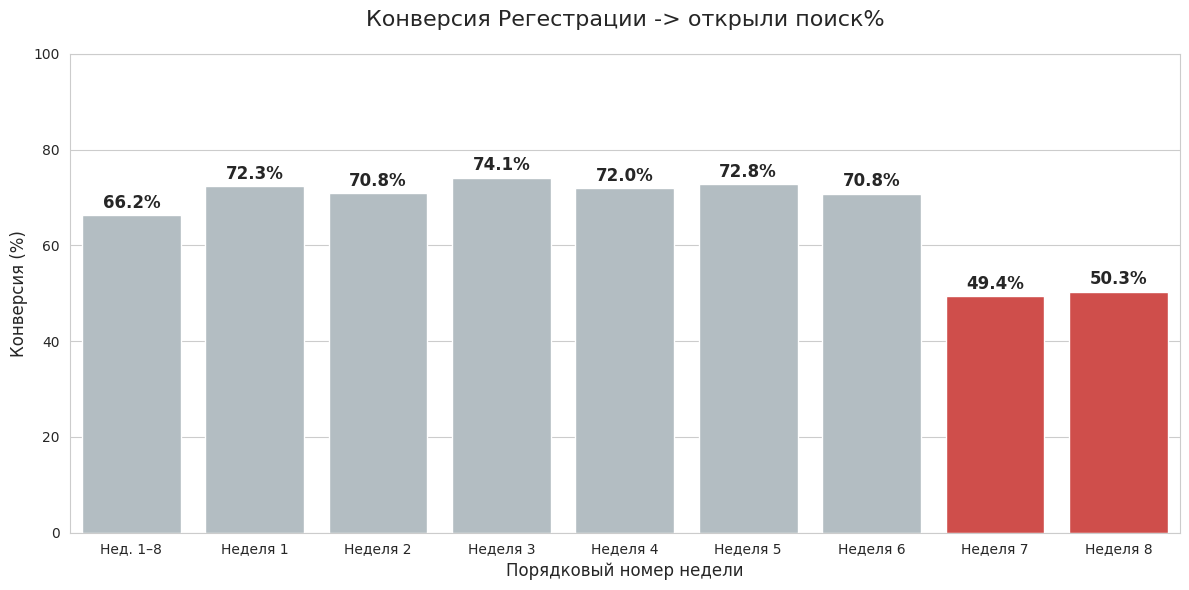

In [15]:
data = {
    'Неделя': df_conv['Неделя'],
    'Конверсия_Регистрация': df_conv['Регестрации -> открыли поиск%']
}

df_vis = pd.DataFrame(data)

# Настройка стиля
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

colors = ['#B0BEC5' if x > 60 else '#E53935' for x in df_vis['Конверсия_Регистрация']]

barplot = sns.barplot(x='Неделя', y='Конверсия_Регистрация', data=df_vis, palette=colors)

for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.1f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=12, fontweight='bold')

plt.title('Конверсия Регестрации -> открыли поиск%', fontsize=16, pad=20)
plt.ylabel('Конверсия (%)', fontsize=12)
plt.xlabel('Порядковый номер недели', fontsize=12)
plt.ylim(0, 100)


plt.tight_layout()
plt.show()

In [21]:
df_weekly['Первая поездка']/df_weekly['Установки']*100
# 'Конверсия на 7 и 8 неделе почему то упала , при том падает она после регестрации'

,0
0,24.426754
1,25.651578
2,26.007067
3,26.448011
4,25.870647
5,26.727146
6,27.487104
7,18.545216
8,19.568063


In [65]:
#Воронка за 7 и 8 неделю
mask_week78 = df[(df['Неделя']=='Неделя 7')|(df['Неделя']=='Неделя 8')]
stages = df.columns[2:]
values_78 = [mask_week78[x].sum() for x in stages]

mask_week16=df[~((df['Неделя']=='Неделя 7')|(df['Неделя']=='Неделя 8')|(df['Неделя']=='Нед. 1–8'))]
values_16 = [mask_week16[x].sum() for x in stages]

fig = go.Figure()
fig.add_trace(go.Funnel(
    name = "Воронка за период 7-8 недель",
    y = stages,
    x = values_78,
    textinfo = "value+percent initial"
))
fig.add_trace(go.Funnel(
    name = "Воронка за период 1-6 недель",
    y = stages,
    x = values_16,

    textinfo = "value+percent initial"
))
fig.add_shape(
    type="rect",
    x0=-2600,   # левая граница (подгони под свои данные)
    x1=2600,  # правая граница
    y0=1.5,   # индекс категории (между "Регистрации" и "Открыли поиск")
    y1=2.5,   # индекс категории (между "Открыли поиск" и следующей)
    line=dict(color="green", width=3),
    fillcolor="rgba(0,0,0,0)"  # прозрачный
)
fig.add_shape(
    type="line",
    x0=-2400,
    x1=-1800,
    y0=2.3,
    y1=2.3,
    line=dict(color="black", width=3)
)

fig.add_shape(
    type="line",
    x0 = 0,
    x1=900,
    y0=2.3,
    y1=2.3,
    line=dict(color="black", width=3)
)

fig.update_layout(title="Воронка конверсии за 1-6 недель и за 7-8 недель")
fig.show()